In [1]:
from sklearn.datasets import fetch_olivetti_faces

data = fetch_olivetti_faces()

In [2]:
train_images = data.images[:300]
test_images = data.images[300:]

In [ ]:
import numpy as np
import pandas as pd


def mkPair(images, no_person):
    pairs = []

    for p in range(no_person):

        person_imgs = images[p * 10 : (p + 1) * 10]

        # 10 positive pairs
        for _ in range(10):
            i, j = np.random.choice(10, 2, replace=False)

            pairs.append([person_imgs[i], person_imgs[j], 1])

        # 10 negative pairs
        for _ in range(10):

            other_p = np.random.choice([x for x in range(no_person) if x != p])

            other_imgs = images[other_p * 10 : (other_p + 1) * 10]

            i = np.random.randint(10)
            j = np.random.randint(10)

            pairs.append([person_imgs[i], other_imgs[j], 0])

    return pd.DataFrame(pairs, columns=["img1", "img2", "label"])

In [4]:
train_pairs = mkPair(train_images, 30)
test_pairs = mkPair(test_images, 10)

In [5]:
# shuffle the dataset
train_pairs = train_pairs.sample(frac=1, random_state=42).reset_index(drop=True)
test_pairs = test_pairs.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
y_train = train_pairs["label"]
X_train = train_pairs.drop(columns=["label"])
y_test = test_pairs["label"]
X_test = test_pairs.drop(columns=["label"])

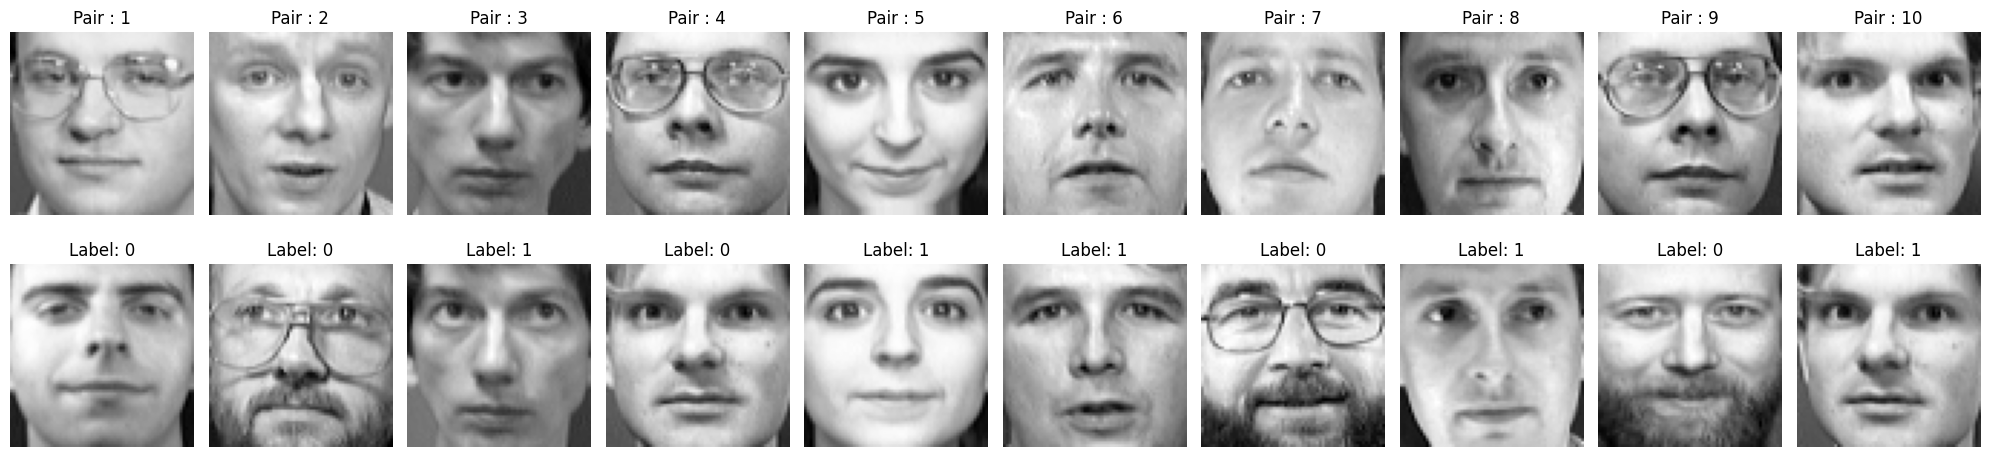

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(20, 5))

for i in range(10):
    img1 = X_train.iloc[i]["img1"]
    img2 = X_train.iloc[i]["img2"]
    label = y_train.iloc[i]

    axes[0, i].imshow(img1, cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(img2, cmap="gray")
    axes[1, i].axis("off")

    axes[1, i].set_title(f"Label: {label}")
    axes[0, i].set_title(f"Pair : {i+1}")

plt.tight_layout()
plt.show()

In [8]:
np.unique_counts(y_train)

UniqueCountsResult(values=array([0, 1]), counts=array([300, 300]))

In [9]:
np.unique_counts(y_test)

UniqueCountsResult(values=array([0, 1]), counts=array([100, 100]))

In [ ]:
class Conv2D:
    def __init__(self, in_channel, out_channel, kernal=3, stride=1, padding=0):
        self.in_channel = in_channel
        self.out_channel = out_channel
        self.kernal = kernal
        self.stride = stride
        self.padding = padding

        self.weights = np.random.randn(out_channel, in_channel, kernal, kernal)
        self.bias = np.zeros(out_channel)

    def forward(self, X):
        N, C, H, W = X.shape

        x_padded = np.pad(
            X,
            (
                (0, 0),
                (0, 0),
                (self.padding, self.padding),
                (self.padding, self.padding),
            ),
            mode="constant",
        )

        O_H = ((H + 2 * self.padding - self.kernal) // self.stride) + 1
        O_W = ((W + 2 * self.padding - self.kernal) // self.stride) + 1

        output = np.zeros((N, self.out_channel, O_H, O_W))

        for n in range(N):
            for oc in range(self.out_channel):
                for i in range(O_H):
                    for j in range(O_W):
                        h_start = i * self.stride
                        w_start = j * self.stride

                        h_end = h_start + self.kernal
                        w_end = w_start + self.kernal

                        output[n, oc, i, j] = (
                            np.sum(
                                x_padded[n, :, h_start:h_end, w_start:w_end]
                                * self.weights[oc]
                            )
                            + self.bias[oc]
                        )

        self.input = (X, x_padded)

        return output